In [169]:
import numpy as np  
import matplotlib.pyplot as plt

#### Can we predict if a GW source will be detected?

In [170]:
import h5py
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [171]:
f.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

The file is very big. Let's downsampling the set for an initial investigation

In [172]:
howmany=int(1e4)

We don't include snr and det (they are the answer)

In [173]:
X=[]
for l in ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']:
    X.append(f[l][:howmany])

X = np.array(X).T
y = np.array(f['det'][:howmany])   #labels (detected or not)

Maybe not all the features are informative or a combination of them is informative

PCA is fine for linear data, let's have a look to the structure of the dataset

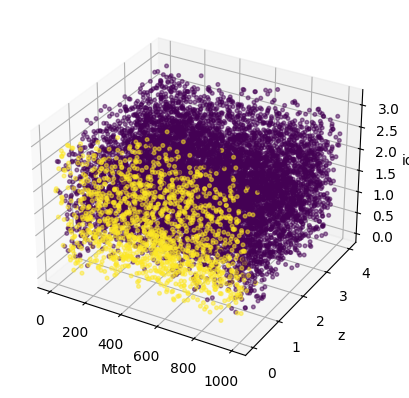

In [174]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,8], X[:,12], X[:,7], c=y, cmap='viridis', marker='o', alpha=0.5, s=7)

ax.set_xlabel('Mtot')
ax.set_ylabel('z')
ax.set_zlabel('iota')


plt.show()

The data set seems to be uniform and z is very informative for the detectability

### Now PCA

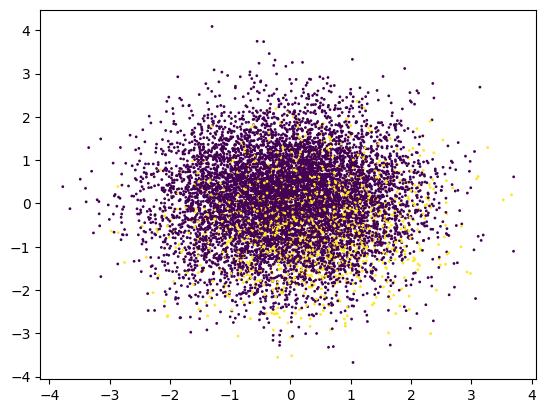

In [175]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xscal = scaler.fit_transform(X)
n_components = 2
pca = PCA(n_components=2)
proj_features = pca.fit_transform(Xscal)
plt.scatter(proj_features[:, 0], proj_features[:, 1], c=y, cmap='viridis', s=1) 

It is not very informative and also the explained variance is poor

In [176]:
s = 0
for idx, r in enumerate(pca.explained_variance_ratio_):
    s += r #for the cumulative 
    print(f"Component {idx+1} explains {100*r:.1f}% of the variance (cumulative = {100*s:.1f})%")

Component 1 explains 8.1% of the variance (cumulative = 8.1)%
Component 2 explains 8.0% of the variance (cumulative = 16.1)%


### Now T-SNE

on scaled and not scaled data

In [177]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,learning_rate=200, perplexity=30, random_state=42)
X_reduced = tsne.fit_transform(Xscal)

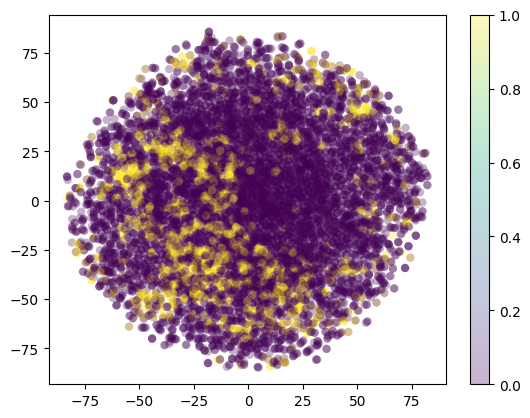

In [178]:
plt.scatter(X_reduced[:,0],X_reduced[:,1], c=y, alpha=0.3, edgecolor="None")
plt.colorbar()

For not rescaled data

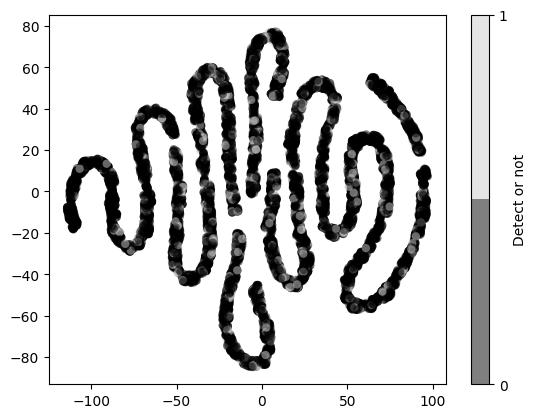

In [179]:
tsne2= TSNE(n_components=2,learning_rate=200, perplexity=30, random_state=42)
X_reduced = tsne2.fit_transform(X)

def discrete_cmap(N, base_cmap=None):
    base = plt.colormaps[base_cmap]
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)
 
plt.scatter(X_reduced[:,0],X_reduced[:,1], c=y, edgecolor='none', alpha=0.5, cmap=discrete_cmap(2,'nipy_spectral'));

plt.colorbar(label='Detect or not', ticks=range(2))
plt.clim(0, 1)

It recognizes the structure related to the mass but not detecyable and not detectable sources

### Selecting some features?


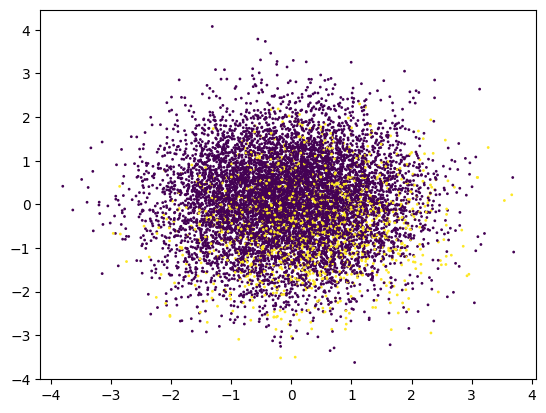

In [180]:
data = X[6::]
Ydata= y[6::]
scaler = StandardScaler()
Xscal = scaler.fit_transform(data)
n_components = 2
pca = PCA(n_components=2)
proj_features = pca.fit_transform(Xscal)
plt.scatter(proj_features[:, 0], proj_features[:, 1], c=Ydata, cmap='viridis', s=1) 


Still the same (I tried also with Isompap)

#### Now Classification with different methods

In [181]:
import sklearn.model_selection

# split the data 
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

#Reduced data for t-sne
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = sklearn.model_selection.train_test_split(X_reduced, y, test_size=0.3, random_state=42)

#Reduced data for PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = sklearn.model_selection.train_test_split(proj_features, Ydata, test_size=0.3, random_state=42)

#### Decision Tree

In [182]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

clf_tsne = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf_tsne.fit(X_train_tsne, y_train_tsne)
y_pred_tsne = clf_tsne.predict(X_test_tsne)

clf_pca = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = clf_pca.predict(X_test_pca)


### Bagging

In [183]:
from sklearn.ensemble import BaggingClassifier
bag_clf = BaggingClassifier(DecisionTreeClassifier(random_state=42), n_estimators=500, max_samples=100, bootstrap=True, random_state=42, n_jobs=-1)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)

Accurancy: number of things classified corretly 

$$ 
{\rm Accurancy} = \frac{\rm TP+TN}{\rm TP+TN+FP+FN}
$$

In [184]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
C2 = sklearn.metrics.confusion_matrix(y_test_tsne, y_pred_tsne)
C3 = sklearn.metrics.confusion_matrix(y_test_pca, y_pred_pca)
C4= sklearn.metrics.confusion_matrix(y_test, y_pred_bag)

print("Confusion Matrix:")
print(C)
print("Confusion Matrix for t-SNE:")
print(C2)     
print("Confusion Matrix for PCA:")
print(C3)
print("Confusion Matrix for Bagging:")
print(C4)

Confusion Matrix:
[[2474   77]
 [  76  373]]
Confusion Matrix for t-SNE:
[[2524   27]
 [ 438   11]]
Confusion Matrix for PCA:
[[2472   83]
 [ 425   19]]
Confusion Matrix for Bagging:
[[2467   84]
 [ 112  337]]


In [185]:
import sklearn.metrics
from sklearn.metrics import accuracy_score 

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Accuracy for t-SNE:", accuracy_score(y_test_tsne, y_pred_tsne))
print("Accuracy for PCA:", accuracy_score(y_test_pca, y_pred_pca))
print("Accuracy for Bagging:", accuracy_score(y_test, y_pred_bag))

Accuracy: 0.949
Accuracy for t-SNE: 0.845
Accuracy for PCA: 0.8306102034011337
Accuracy for Bagging: 0.9346666666666666


In [186]:
print("Precision:", sklearn.metrics.precision_score(y_test, y_pred))
print("Precision for t-SNE:", sklearn.metrics.precision_score(y_test_tsne, y_pred_tsne))
print("Precision for PCA:", sklearn.metrics.precision_score(y_test_pca, y_pred_pca))
print("Precision for Bagging:", sklearn.metrics.precision_score(y_test, y_pred_bag))


Precision: 0.8288888888888889
Precision for t-SNE: 0.2894736842105263
Precision for PCA: 0.18627450980392157
Precision for Bagging: 0.8004750593824228


### ROC curve

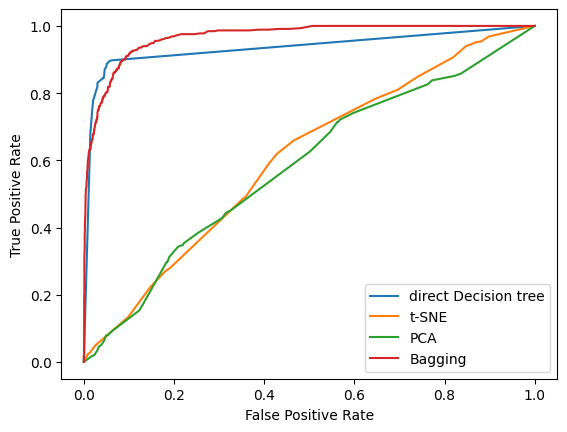

In [ ]:
y_prob = clf.predict_proba(X_test)[:,1]
y_prob_tsne = clf_tsne.predict_proba(X_test_tsne)[:,1]
y_prob_pca = clf_pca.predict_proba(X_test_pca)[:,1]
y_prob_bag = bag_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, y_prob)
fpr_tsne, tpr_tsne, thresholds_tsne = sklearn.metrics.roc_curve(y_test_tsne, y_prob_tsne)
fpr_pca, tpr_pca, thresholds_pca = sklearn.metrics.roc_curve(y_test_pca, y_prob_pca)
fpr_bag, tpr_bag, thresholds_bag = sklearn.metrics.roc_curve(y_test, y_prob_bag)

plt.plot(fpr, tpr, label='direct Decision tree');
plt.plot(fpr_tsne, tpr_tsne, label='t-SNE')
plt.plot(fpr_pca, tpr_pca, label='PCA')
plt.plot(fpr_bag, tpr_bag, label='Bagging')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()


In [188]:
importances = clf.feature_importances_
features_importance = np.argsort(importances)[::-1]     

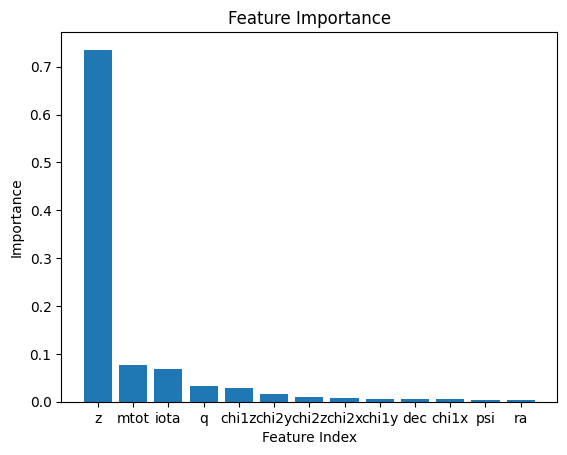

In [189]:
# Plotting feature importance
features_importance = np.argsort(importances)[::-1]  # Rank importances (highest to lowest)

feature_names = ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']
features_importance2 = [feature_names[i] for i in features_importance]
plt.bar(range(len(importances)), importances[features_importance], align='center')
plt.xticks(range(len(importances)), features_importance2)  
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

The redshift seems to be far more informative then the other features

### Histogram of the redshift

Text(0.5, 0, 'z')

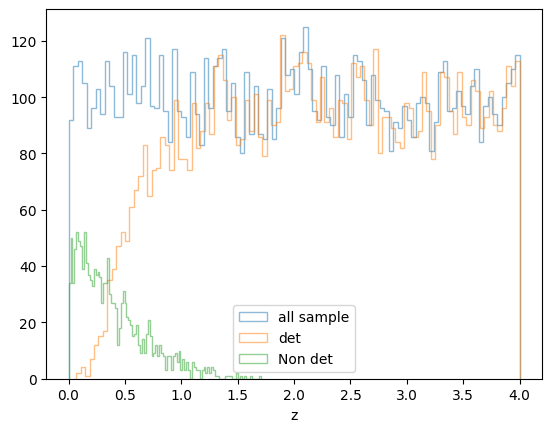

In [190]:
plt.hist(X[:,12], bins=100, alpha=0.5, label='all sample', histtype='step')
plt.hist(X[:,12][y==0], bins=100, alpha=0.5, label='det', histtype='step')
plt.hist(X[:,12][y==1], bins=100, alpha=0.5, label='Non det', histtype='step');
plt.legend()
plt.xlabel('z')

Let's investigate the depth of the Tree (at some point there is OVERFITTING)

In [191]:
howmany=int(1e5)

X=[]
for l in ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']:
    X.append(f[l][:howmany])

X = np.array(X).T
y = np.array(f['det'][:howmany])   #labels (detected or not)


X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

md_vals = np.arange(1,20)
for md in md_vals:
    clf = DecisionTreeClassifier(random_state=42, max_depth=md,criterion='entropy')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    C = sklearn.metrics.confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_test.append(tp/(tp+fn))
    contamination_test.append(fp/(tp+fp))

    y_pred = clf.predict(X_train)
    C = sklearn.metrics.confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_train.append(tp/(tp+fn))
    contamination_train.append(fp/(tp+fp))
    

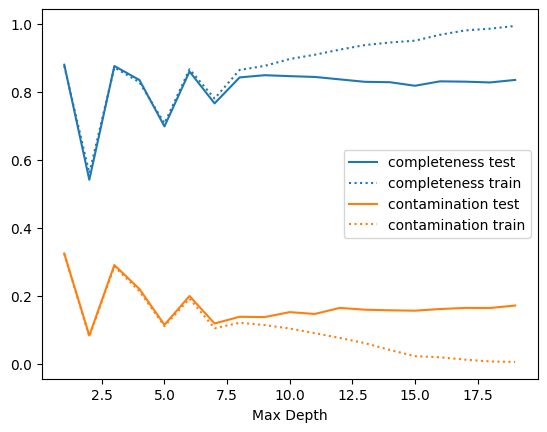

In [192]:
plt.plot(md_vals,completeness_test,label='completeness test',c='C0')
plt.plot(md_vals,completeness_train,label='completeness train',c='C0',ls='dotted')

plt.plot(md_vals,contamination_test,label='contamination test',c='C1')
plt.plot(md_vals,contamination_train,label='contamination train',c='C1',ls='dotted')
plt.xlabel('Max Depth')
plt.legend();

At depth of 7 it starts overfitting

In [193]:
print("completeness test", np.array(completeness_test)[md_vals==7])
print("contamination test", np.array(contamination_test)[md_vals==7])
print("completeness train", np.array(completeness_train)[md_vals==7])
print("contamination train", np.array(contamination_train)[md_vals==7])

completeness test [0.76561777]
contamination test [0.11900958]
completeness train [0.77992048]
contamination train [0.10515511]


#### Random Forest?

In [194]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200, max_depth=7, criterion='entropy',n_jobs=-1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = C.ravel()
print("completeness test", tp/(tp+fn))
print("contamination test", fp/(tp+fp))

y_pred = clf.predict(X_train)
C = sklearn.metrics.confusion_matrix(y_train, y_pred)
tn, fp, fn, tp = C.ravel()
print("completeness train", tp/(tp+fn))
print("contamination train", fp/(tp+fp))

completeness test 0.8003239241092087
contamination test 0.09592263460533194
completeness train 0.8105367793240557
contamination train 0.08597690841833876


## LAST LECTURE

#### DEEP LEARNING NOW

In [195]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

Rescale data first

In [196]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cross validation on the learning rate in order to maximize accuracy

In [197]:
#Base model
mlp = MLPClassifier(hidden_layer_sizes=(5,), activation='relu', solver='adam', max_iter=500, random_state=42)

# Grid for the learning rate
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1]  #it is the learning rate
}

# GridSearchCV
grid = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=MLPClassifier(hidden_layer_sizes=(5,), max_iter=500,
                                     random_state=42),
             n_jobs=-1, param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1]},
             scoring='accuracy')

In [198]:
print("Best Classifier found:")
print(grid.best_params_)

test_accuracy = grid.score(X_test_scaled, y_test)
print(f"Accurancy on the test: {test_accuracy:.3f}")

Best Classifier found:
{'alpha': 0.01}
Accurancy on the test: 0.962


Perform a MLP with the best learning rate

In [199]:
mlp_best = grid.best_estimator_
mlp_best.fit(X_train_scaled, y_train)
y_pred_MPL = mlp_best.predict(X_test_scaled)
y_prob_MPL = mlp_best.predict_proba(X_test_scaled)[:,1]

Random forest for comparison

In [200]:
clf = RandomForestClassifier(n_estimators=200, max_depth=7, criterion='entropy',n_jobs=-1)
clf.fit(X_train, y_train)
y_pred_RF = clf.predict(X_test)
y_prob_RF = clf.predict_proba(X_test)[:,1]

Bagging for comparison

In [202]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(random_state=42), n_estimators=500, max_samples=100, bootstrap=True, random_state=42, n_jobs=-1)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
y_prob_bag = bag_clf.predict_proba(X_test)[:,1]

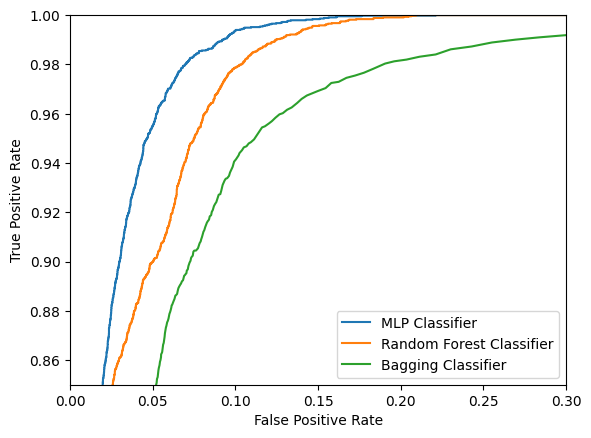

In [204]:
from sklearn.metrics import roc_curve 

#ROC Curve and accuracy:
fpr, tpr, thresh = roc_curve(y_test, y_prob_MPL) 
fpr_RF, tpr_RF, thresh_RF = roc_curve(y_test, y_prob_RF) 
fpr_bag, tpr_bag, thresh_bag = roc_curve(y_test, y_prob_bag)

plt.plot(fpr, tpr, label='MLP Classifier')
plt.plot(fpr_RF, tpr_RF, label='Random Forest Classifier')
plt.plot(fpr_bag, tpr_bag, label='Bagging Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.xlim(0,0.3)
plt.ylim(0.85,1)
plt.show()


In [205]:
accurcy_RF = accuracy_score(y_test, y_pred_RF)
accuracy_MLP = accuracy_score(y_test, y_pred_MPL)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print(f"Accuracy MLP: {accuracy_MLP:.3f}")
print(f"Accuracy Random Forest: {accurcy_RF:.3f}")  
print(f"Accuracy Bagging: {accuracy_bag:.3f}")

Accuracy MLP: 0.962
Accuracy Random Forest: 0.959
Accuracy Bagging: 0.942
